In [77]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashtcoder/network-data-schema-in-the-netflow-v9-format")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/ashtcoder/network-data-schema-in-the-netflow-v9-format/versions/2


In [78]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import os

In [79]:
# Check available files
directory_path = "/root/.cache/kagglehub/datasets/ashtcoder/network-data-schema-in-the-netflow-v9-format/versions/2"
files = os.listdir(directory_path)
print("Available files:", files)


Available files: ['train_net.csv', 'test_net.csv']


In [80]:
# Load datasets
train_path = os.path.join(directory_path, "train_net.csv")
test_path = os.path.join(directory_path, "test_net.csv")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)


Train Data Shape: (4217625, 33)
Test Data Shape: (2077339, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4217625 entries, 0 to 4217624
Data columns (total 33 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   FLOW_ID                     int64  
 1   PROTOCOL_MAP                object 
 2   L4_SRC_PORT                 int64  
 3   IPV4_SRC_ADDR               object 
 4   L4_DST_PORT                 int64  
 5   IPV4_DST_ADDR               object 
 6   FIRST_SWITCHED              int64  
 7   FLOW_DURATION_MILLISECONDS  int64  
 8   LAST_SWITCHED               int64  
 9   PROTOCOL                    int64  
 10  TCP_FLAGS                   int64  
 11  TCP_WIN_MAX_IN              int64  
 12  TCP_WIN_MAX_OUT             int64  
 13  TCP_WIN_MIN_IN              int64  
 14  TCP_WIN_MIN_OUT             int64  
 15  TCP_WIN_MSS_IN              int64  
 16  TCP_WIN_SCALE_IN            int64  
 17  TCP_WIN_SCALE_OUT           int64  
 18 

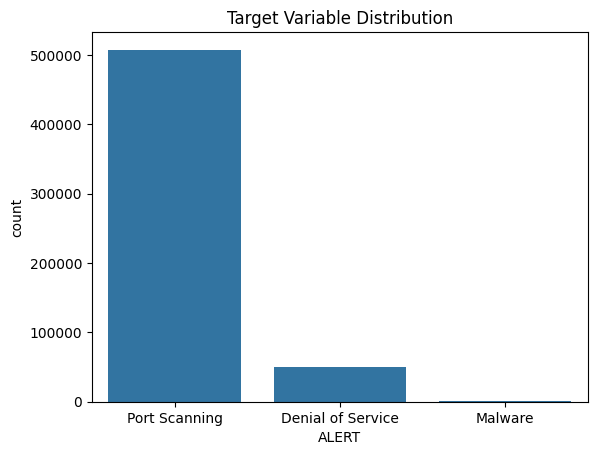

In [81]:


# EDA: Check dataset structure and target distribution
print("Train Data Shape:", train_df.shape)
print("Test Data Shape:", test_df.shape)
print(train_df.info())
sns.countplot(x='ALERT', data=train_df)
plt.title('Target Variable Distribution')
plt.show()


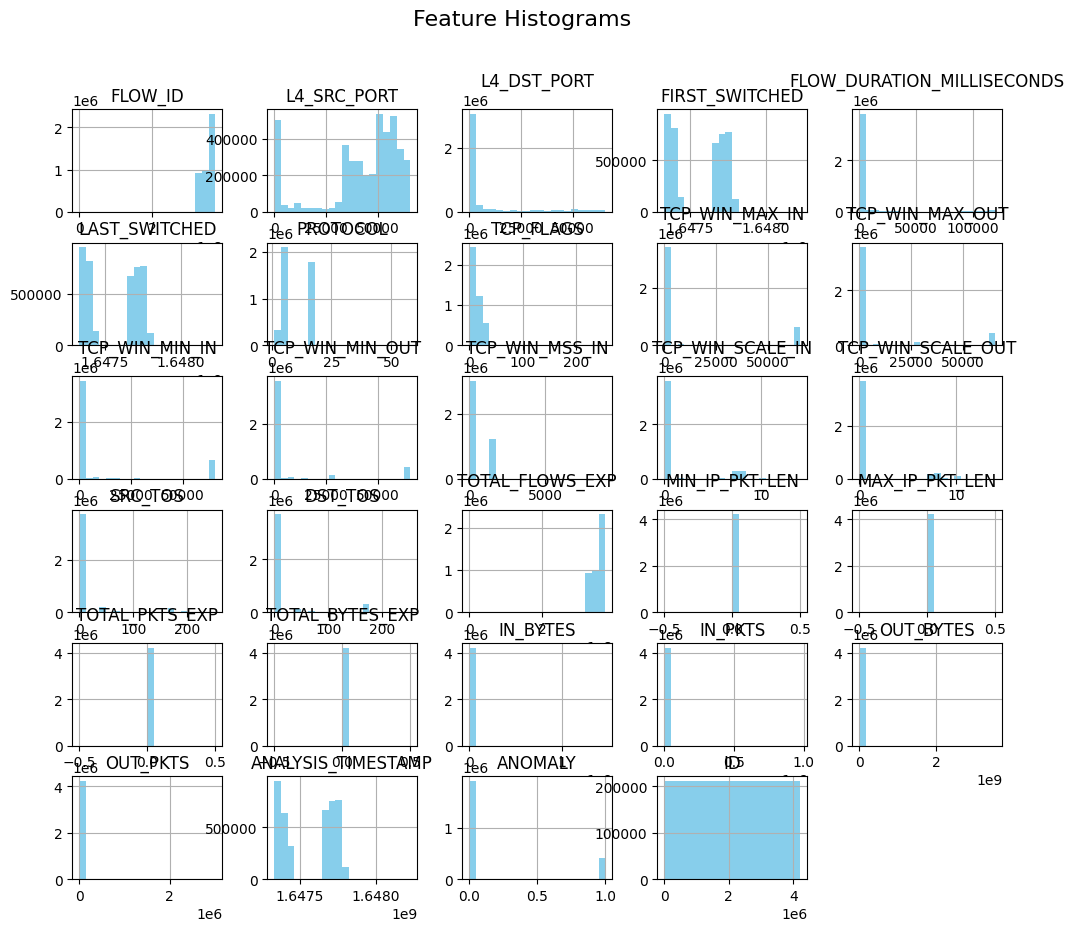

In [82]:

# Histogram
train_df.hist(figsize=(12, 10), bins=20, color='skyblue')
plt.suptitle("Feature Histograms", fontsize=16)
plt.show()



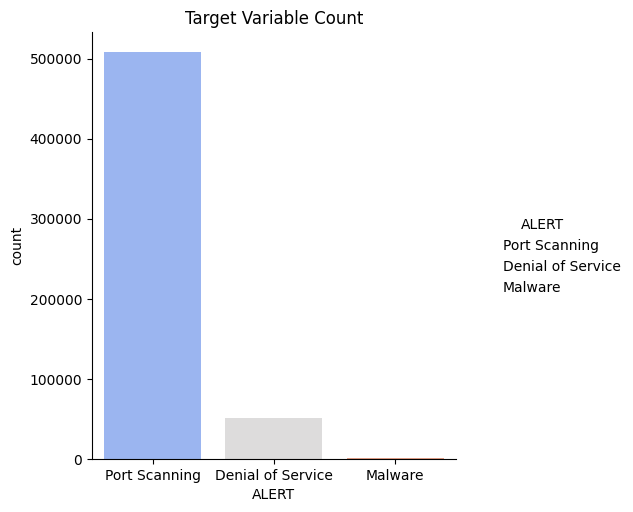

In [83]:
# Catplot
sns.catplot(x='ALERT', kind='count', data=train_df, palette='coolwarm')
plt.title("Target Variable Count")
plt.show()

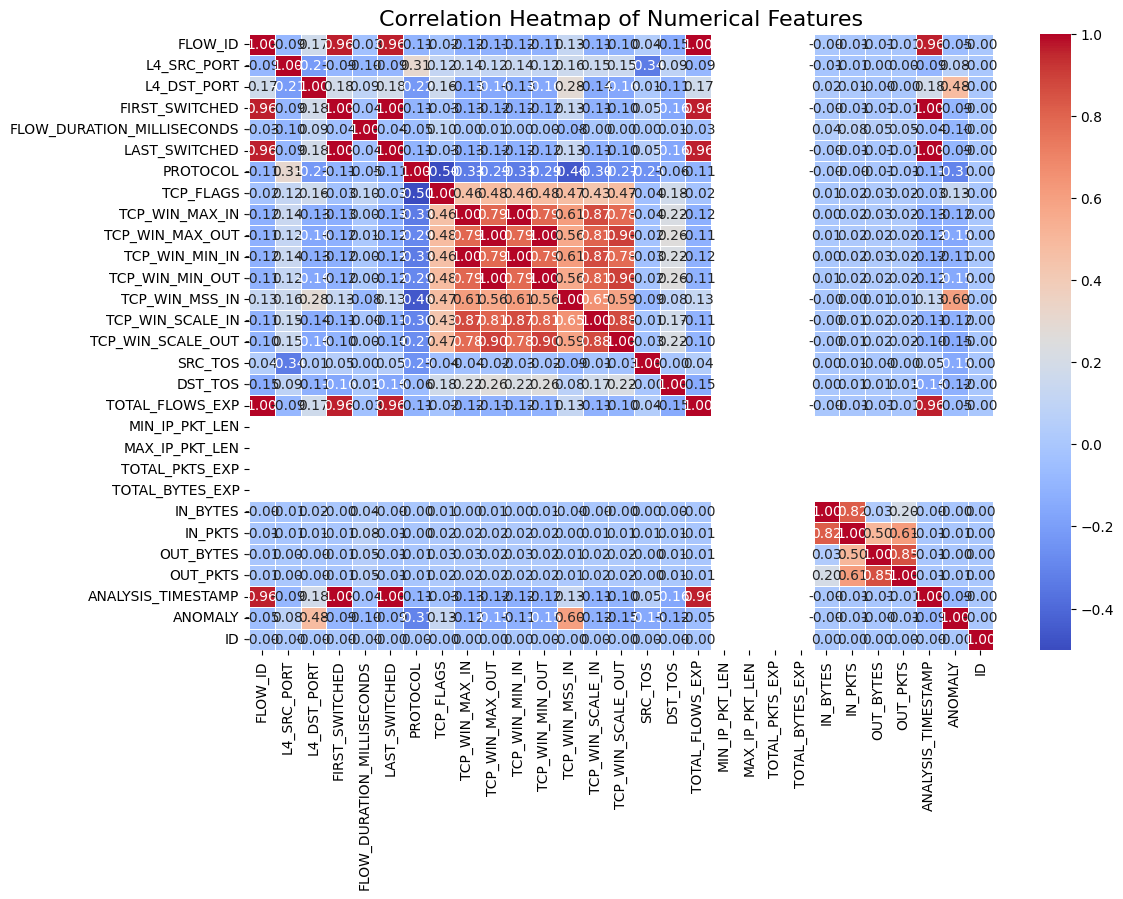

In [84]:
# 1. Correlation Heatmap (Numerical Features)
numerical_features = train_df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12, 8))
correlation_matrix = numerical_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.show()



In [ ]:
# Handle missing values
train_df.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)

# Remove duplicate rows
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

# Convert ALERT column to a consistent type
try:
    train_df['ALERT'] = train_df['ALERT'].astype(int)
except ValueError:
    print("Non-integer values detected in 'ALERT'. Converting to string.")
    train_df['ALERT'] = train_df['ALERT'].astype(str)

# Verify cleaned ALERT column
print("Unique values in ALERT column after cleaning:", train_df['ALERT'].unique())


Non-integer values detected in 'ALERT'. Converting to string.
Unique values in ALERT column after cleaning: ['Port Scanning' '0' 'Denial of Service' 'Malware']


In [ ]:
# Drop irrelevant or constant columns
columns_to_drop = [
    'FLOW_ID', 'ID', 'ANALYSIS_TIMESTAMP', 'IPV4_SRC_ADDR',
    'IPV4_DST_ADDR', 'PROTOCOL_MAP', 'MIN_IP_PKT_LEN',
    'MAX_IP_PKT_LEN', 'TOTAL_PKTS_EXP', 'TOTAL_BYTES_EXP'
]
train_df.drop(columns=columns_to_drop, axis=1, inplace=True)
test_df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [ ]:

# Split features and target
X = train_df.drop('ALERT', axis=1)
y = train_df['ALERT']


In [ ]:

# Stratified split to maintain target distribution
def stratified_split(X, y, test_size=0.2, random_state=42):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, val_idx = next(sss.split(X, y))
    return X.iloc[train_idx], X.iloc[val_idx], y.iloc[train_idx], y.iloc[val_idx]


In [ ]:

X_train, X_val, y_train, y_val = stratified_split(X, y)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:

# Check if 'ALERT' exists in test_df before dropping
if 'ALERT' in test_df.columns:
    X_test_scaled = scaler.transform(test_df.drop('ALERT', axis=1))
else:
    X_test_scaled = scaler.transform(test_df)

# Train Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:

# Feature importance
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rfc.feature_importances_
}).sort_values('importance', ascending=False)
print("Feature Importances:\n", feature_importances)

# Select important features (threshold > 0.02)
important_features = feature_importances[feature_importances['importance'] > 0.02]['feature']
X_train_selected = X_train[important_features]
X_val_selected = X_val[important_features]
X_test_selected = test_df[important_features]


Feature Importances:
                        feature  importance
21                     ANOMALY    0.165717
11              TCP_WIN_MSS_IN    0.154925
17                    IN_BYTES    0.117343
7               TCP_WIN_MAX_IN    0.090431
9               TCP_WIN_MIN_IN    0.082674
1                  L4_DST_PORT    0.082490
2               FIRST_SWITCHED    0.041471
16             TOTAL_FLOWS_EXP    0.035660
3   FLOW_DURATION_MILLISECONDS    0.034886
4                LAST_SWITCHED    0.031479
19                   OUT_BYTES    0.026506
18                     IN_PKTS    0.025733
0                  L4_SRC_PORT    0.022700
8              TCP_WIN_MAX_OUT    0.018454
6                    TCP_FLAGS    0.015157
12            TCP_WIN_SCALE_IN    0.014926
10             TCP_WIN_MIN_OUT    0.011489
20                    OUT_PKTS    0.009155
14                     SRC_TOS    0.008708
13           TCP_WIN_SCALE_OUT    0.005471
5                     PROTOCOL    0.002633
15                     DST_TOS  

In [ ]:
# Support Vector Machine
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Define the SVM model
svm = SVC(random_state=42)

# Define parameter grid for GridSearchCV
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Perform Grid Search with Cross Validation
grid_svm = GridSearchCV(svm, param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

# Best parameters and cross-validation accuracy
print(f"SVM - Best Params: {grid_svm.best_params_}")
print(f"SVM - Best Cross-Validation Accuracy: {grid_svm.best_score_}")

# Predictions on validation data
y_pred_svm = grid_svm.best_estimator_.predict(X_val_scaled)
print("SVM - Validation Classification Report:\n", classification_report(y_val, y_pred_svm))

# Extract performance for plotting
mean_test_scores_svm = grid_svm.cv_results_['mean_test_score']

# Generate labels for grid parameters
param_labels_svm = [
    f"C: {C}, Kernel: {kernel}, Gamma: {gamma}"
    for C, kernel, gamma in zip(
        grid_svm.cv_results_['param_C'],
        grid_svm.cv_results_['param_kernel'],
        grid_svm.cv_results_['param_gamma']
    )
]

# Plot SVM performance
plt.figure(figsize=(12, 6))
plt.plot(param_labels_svm, mean_test_scores_svm, marker='o', label="Validation Accuracy")
plt.xlabel('C, Kernel, and Gamma')
plt.ylabel('Accuracy')
plt.title('SVM Performance')
plt.xticks(rotation=45, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()



KeyboardInterrupt: 

In [ ]:
import pickle

# Save the best XGBoost model
xgb_model_filename = "xgboost_model.pkl"
with open(xgb_model_filename, 'wb') as f:
    pickle.dump(grid_xgb.best_estimator_, f)

print(f"XGBoost model saved as {xgb_model_filename}")


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix for SVM
cm_svm = confusion_matrix(y_val, y_pred_svm)

# Display confusion matrix
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=grid_svm.best_estimator_.classes_)
disp_svm.plot(cmap=plt.cm.Blues)
plt.title("SVM - Confusion Matrix")
plt.show()


Best K: 1
Best Cross-Validation Accuracy: 0.9986860693715855


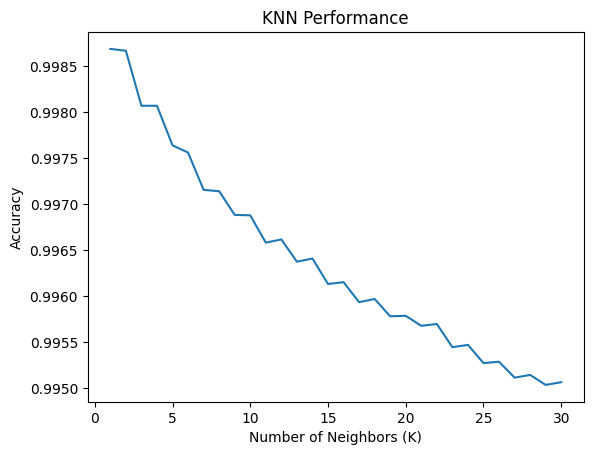

Validation Classification Report:
                    precision    recall  f1-score   support

                0       1.00      1.00      1.00     43918
Denial of Service       0.99      1.00      0.99       603
          Malware       1.00      1.00      1.00         7
    Port Scanning       0.99      1.00      1.00      6084

         accuracy                           1.00     50612
        macro avg       0.99      1.00      1.00     50612
     weighted avg       1.00      1.00      1.00     50612



In [ ]:

# Optimize KNN with GridSearchCV
param_grid = {'n_neighbors': range(1, 31)}
knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

# Print results of GridSearch
print(f"Best K: {grid.best_params_['n_neighbors']}")
print(f"Best Cross-Validation Accuracy: {grid.best_score_}")

# Plot KNN performance
plt.plot(param_grid['n_neighbors'], grid.cv_results_['mean_test_score'])
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Performance')
plt.show()

# Evaluate model on validation data
y_pred = grid.best_estimator_.predict(X_val_scaled)
print("Validation Classification Report:\n", classification_report(y_val, y_pred))


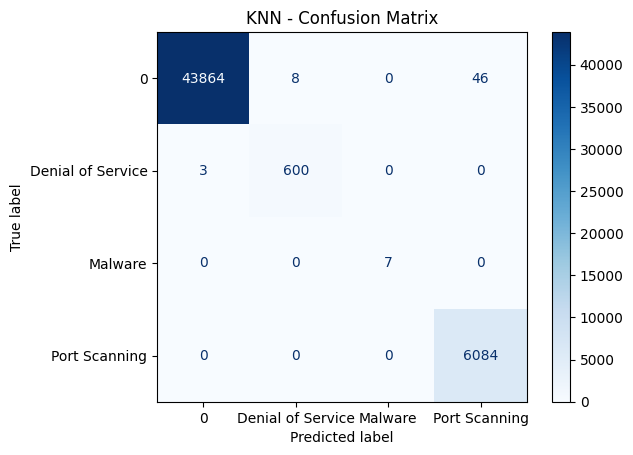

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix for KNN
cm_knn = confusion_matrix(y_val, y_pred)

# Display confusion matrix
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=grid.best_estimator_.classes_)
disp_knn.plot(cmap=plt.cm.Blues)
plt.title("KNN - Confusion Matrix")
plt.show()


In [ ]:
import pickle

# Save the best KNN model
model_filename = "knn_model.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(grid.best_estimator_, f)

print(f"KNN model saved as {model_filename}")


KNN model saved as knn_model.pkl


Random Forest - Best Params: {'max_depth': None, 'n_estimators': 50}
Random Forest - Best Cross-Validation Accuracy: 0.9997925372691977
Random Forest - Validation Classification Report:
                    precision    recall  f1-score   support

                0       1.00      1.00      1.00     43918
Denial of Service       1.00      1.00      1.00       603
          Malware       1.00      1.00      1.00         7
    Port Scanning       1.00      1.00      1.00      6084

         accuracy                           1.00     50612
        macro avg       1.00      1.00      1.00     50612
     weighted avg       1.00      1.00      1.00     50612



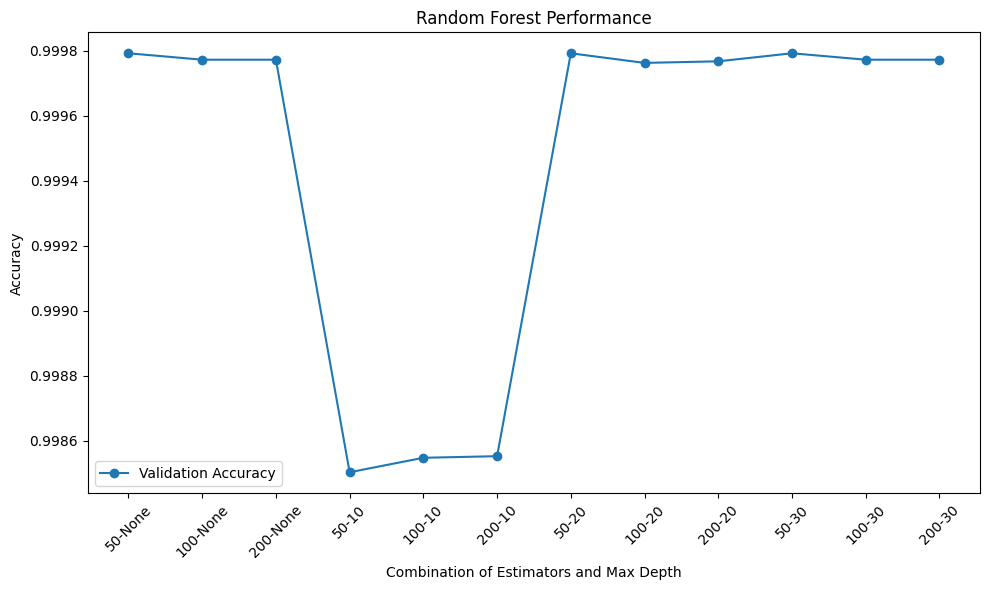

In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

print(f"Random Forest - Best Params: {grid_rf.best_params_}")
print(f"Random Forest - Best Cross-Validation Accuracy: {grid_rf.best_score_}")

y_pred_rf = grid_rf.best_estimator_.predict(X_val_scaled)
print("Random Forest - Validation Classification Report:\n", classification_report(y_val, y_pred_rf))

# Plot Random Forest performance
mean_test_scores = grid_rf.cv_results_['mean_test_score']
param_n_estimators = [f"{n_est}-{depth}" for n_est, depth in zip(grid_rf.cv_results_['param_n_estimators'], grid_rf.cv_results_['param_max_depth'])]

plt.figure(figsize=(10, 6))
plt.plot(param_n_estimators, mean_test_scores, marker='o', label="Validation Accuracy")
plt.xlabel('Combination of Estimators and Max Depth')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


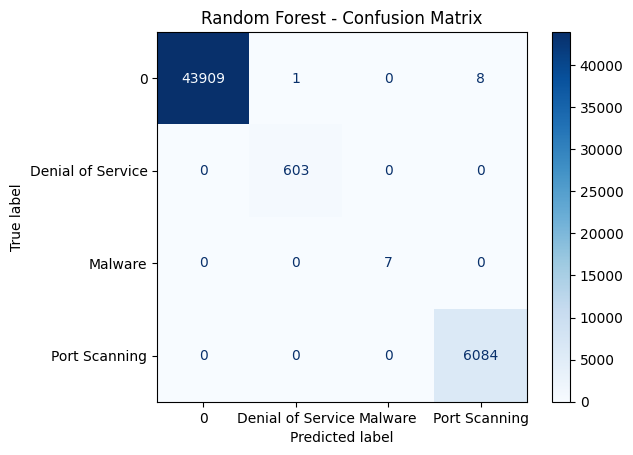

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix for Random Forest
cm_rf = confusion_matrix(y_val, y_pred_rf)

# Display confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=grid_rf.best_estimator_.classes_)
disp_rf.plot(cmap=plt.cm.Blues)
plt.title("Random Forest - Confusion Matrix")
plt.show()


In [ ]:
import pickle

# Save the best Random Forest model
rf_model_filename = "random_forest_model.pkl"
with open(rf_model_filename, 'wb') as f:
    pickle.dump(grid_rf.best_estimator_, f)

print(f"Random Forest model saved as {rf_model_filename}")


Random Forest model saved as random_forest_model.pkl


Decision Tree - Best Params: {'max_depth': None, 'min_samples_split': 5}
Decision Tree - Best Cross-Validation Accuracy: 0.9994517056400225
Decision Tree - Validation Classification Report:
                    precision    recall  f1-score   support

                0       1.00      1.00      1.00     43918
Denial of Service       1.00      1.00      1.00       603
          Malware       1.00      1.00      1.00         7
    Port Scanning       1.00      1.00      1.00      6084

         accuracy                           1.00     50612
        macro avg       1.00      1.00      1.00     50612
     weighted avg       1.00      1.00      1.00     50612



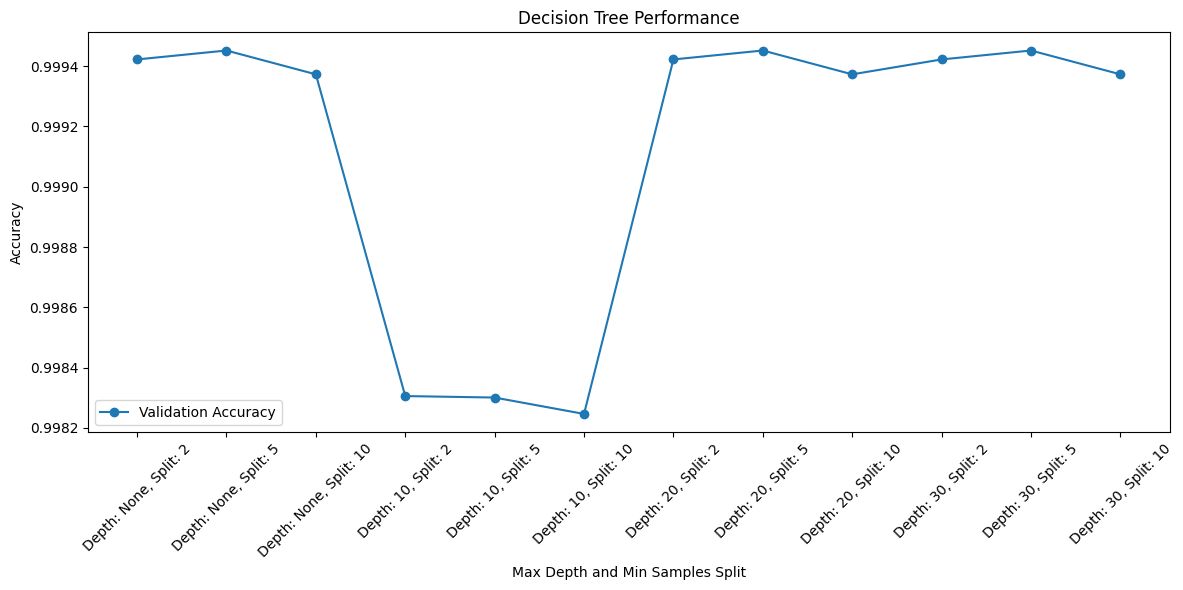

In [ ]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=3, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)

# Best parameters and cross-validation accuracy
print(f"Decision Tree - Best Params: {grid_dt.best_params_}")
print(f"Decision Tree - Best Cross-Validation Accuracy: {grid_dt.best_score_}")

# Predictions on validation data
y_pred_dt = grid_dt.best_estimator_.predict(X_val_scaled)
print("Decision Tree - Validation Classification Report:\n", classification_report(y_val, y_pred_dt))

# Extract performance for plotting
mean_test_scores_dt = grid_dt.cv_results_['mean_test_score']

# Generate labels for grid parameters
param_labels_dt = [
    f"Depth: {depth}, Split: {split}"
    for depth, split in zip(grid_dt.cv_results_['param_max_depth'], grid_dt.cv_results_['param_min_samples_split'])
]

# Plot Decision Tree performance
plt.figure(figsize=(12, 6))
plt.plot(param_labels_dt, mean_test_scores_dt, marker='o', label="Validation Accuracy")
plt.xlabel('Max Depth and Min Samples Split')
plt.ylabel('Accuracy')
plt.title('Decision Tree Performance')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()


plt.show()


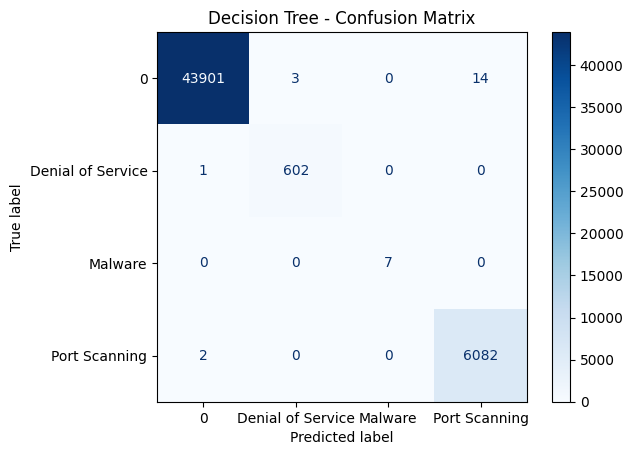

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_val, y_pred_dt)

# Display confusion matrix
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=grid_dt.best_estimator_.classes_)
disp_dt.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree - Confusion Matrix")
plt.show()


In [ ]:
import pickle

# Save the best Decision Tree model
dt_model_filename = "decision_tree_model.pkl"
with open(dt_model_filename, 'wb') as f:
    pickle.dump(grid_dt.best_estimator_, f)

print(f"Decision Tree model saved as {dt_model_filename}")


Decision Tree model saved as decision_tree_model.pkl


In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 9.3 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CatBoost - Best Params: {'depth': 6, 'iterations': 500, 'learning_rate': 0.2}
CatBoost - Best Cross-Validation Accuracy: 0.9997233830255969
CatBoost - Validation Classification Report:
                    precision    recall  f1-score   support

                0       1.00      1.00      1.00     43918
Denial of Service       1.00      1.00      1.00       603
          Malware       1.00      1.00      1.00         7
    Port Scanning       1.00      1.00      1.00      6084

         accuracy                           1.00     50612
        macro avg       1.00      1.00      1.00     50612
     weighted avg       1.00      1.00      1.00     50612



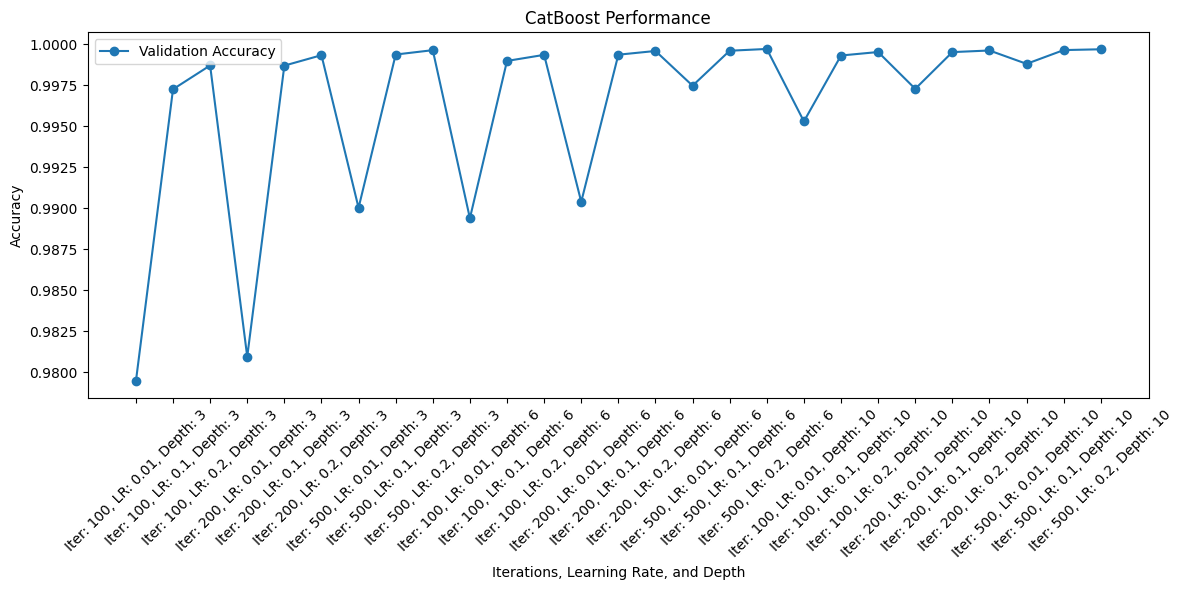

In [ ]:
# CatBoost
from catboost import CatBoostClassifier

cat = CatBoostClassifier(random_state=42, verbose=0)
param_grid_cat = {
    'iterations': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [3, 6, 10]
}
grid_cat = GridSearchCV(cat, param_grid_cat, cv=3, scoring='accuracy', n_jobs=-1)
grid_cat.fit(X_train_scaled, y_train)

# Best parameters and cross-validation accuracy
print(f"CatBoost - Best Params: {grid_cat.best_params_}")
print(f"CatBoost - Best Cross-Validation Accuracy: {grid_cat.best_score_}")

# Predictions on validation data
y_pred_cat = grid_cat.best_estimator_.predict(X_val_scaled)
print("CatBoost - Validation Classification Report:\n", classification_report(y_val, y_pred_cat))

# Extract performance for plotting
mean_test_scores_cat = grid_cat.cv_results_['mean_test_score']

# Generate labels for grid parameters
param_labels_cat = [
    f"Iter: {iter}, LR: {lr}, Depth: {depth}"
    for iter, lr, depth in zip(
        grid_cat.cv_results_['param_iterations'],
        grid_cat.cv_results_['param_learning_rate'],
        grid_cat.cv_results_['param_depth']
    )
]

# Plot CatBoost performance
plt.figure(figsize=(12, 6))
plt.plot(param_labels_cat, mean_test_scores_cat, marker='o', label="Validation Accuracy")
plt.xlabel('Iterations, Learning Rate, and Depth')
plt.ylabel('Accuracy')
plt.title('CatBoost Performance')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Optional: Confusion matrix visualization (if implemented)
# plot_confusion_matrix(y_val, y_pred_cat, "CatBoost")

plt.show()


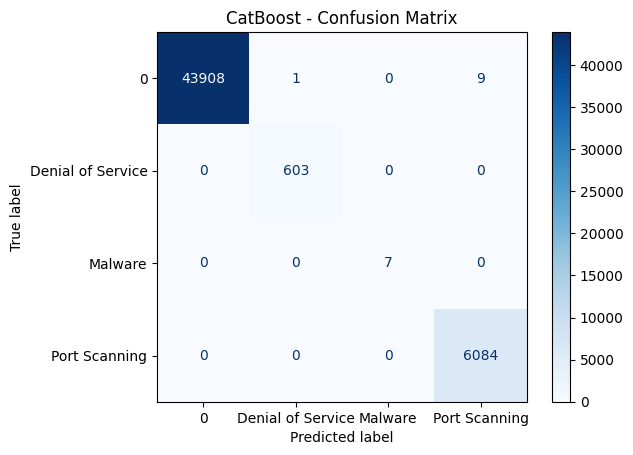

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix for CatBoost
cm_cat = confusion_matrix(y_val, y_pred_cat)

# Display confusion matrix
disp_cat = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=grid_cat.best_estimator_.classes_)
disp_cat.plot(cmap=plt.cm.Blues)
plt.title("CatBoost - Confusion Matrix")
plt.show()


In [ ]:
import pickle

# Save the best CatBoost model
cat_model_filename = "catboost_model.pkl"
with open(cat_model_filename, 'wb') as f:
    pickle.dump(grid_cat.best_estimator_, f)

print(f"CatBoost model saved as {cat_model_filename}")


CatBoost model saved as catboost_model.pkl


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:01:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost - Best Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
XGBoost - Best Cross-Validation Accuracy: 0.9997925372691977
XGBoost - Validation Classification Report:
                    precision    recall  f1-score   support

                0       1.00      1.00      1.00     21978
Denial of Service       1.00      1.00      1.00       303
          Malware       1.00      1.00      1.00         4
    Port Scanning       1.00      1.00      1.00      3021

         accuracy                           1.00     25306
        macro avg       1.00      1.00      1.00     25306
     weighted avg       1.00      1.00      1.00     25306



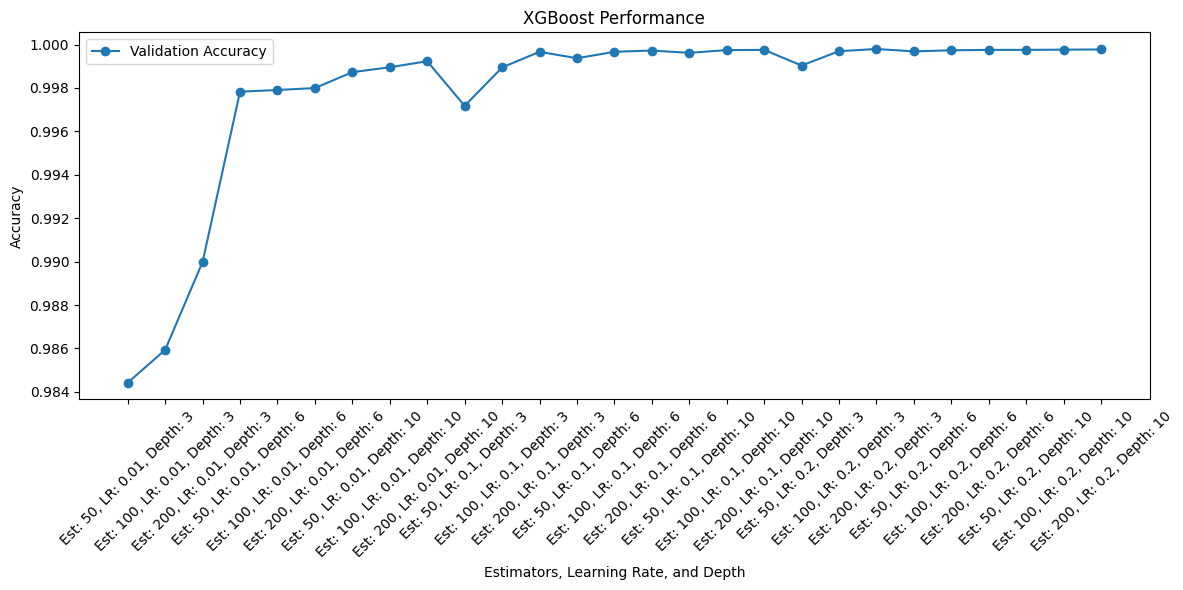

In [ ]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Encode labels if necessary
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

# Define and train XGBoost
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 10]
}
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train_encoded)

# Best parameters and cross-validation accuracy
print(f"XGBoost - Best Params: {grid_xgb.best_params_}")
print(f"XGBoost - Best Cross-Validation Accuracy: {grid_xgb.best_score_}")

# Predictions on validation data
y_pred_xgb_encoded = grid_xgb.best_estimator_.predict(X_val_scaled)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

print("XGBoost - Validation Classification Report:\n", classification_report(y_val, y_pred_xgb))

# Extract performance for plotting
mean_test_scores_xgb = grid_xgb.cv_results_['mean_test_score']

# Generate labels for grid parameters
param_labels_xgb = [
    f"Est: {est}, LR: {lr}, Depth: {depth}"
    for est, lr, depth in zip(
        grid_xgb.cv_results_['param_n_estimators'],
        grid_xgb.cv_results_['param_learning_rate'],
        grid_xgb.cv_results_['param_max_depth']
    )
]

# Plot XGBoost performance
plt.figure(figsize=(12, 6))
plt.plot(param_labels_xgb, mean_test_scores_xgb, marker='o', label="Validation Accuracy")
plt.xlabel('Estimators, Learning Rate, and Depth')
plt.ylabel('Accuracy')
plt.title('XGBoost Performance')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Optional: Confusion matrix visualization (if implemented)
# plot_confusion_matrix(y_val, y_pred_xgb, "XGBoost")

plt.show()


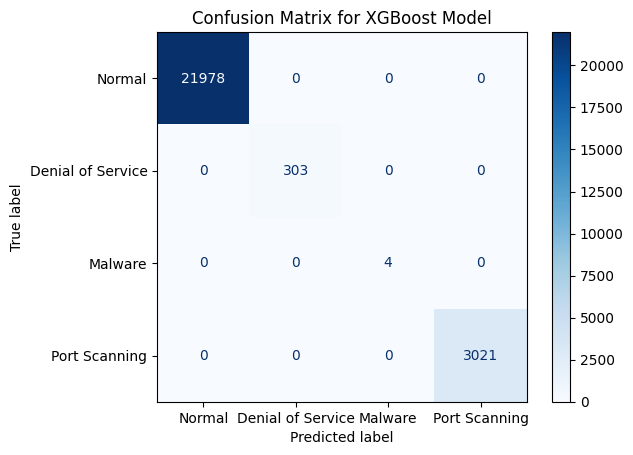

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions on validation data
y_pred_xgb_encoded = grid_xgb.best_estimator_.predict(X_val_scaled)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

print("XGBoost - Validation Classification Report:\n", classification_report(y_val, y_pred_xgb))

# Compute confusion matrix
conf_matrix = confusion_matrix(y_val, y_pred_xgb, labels=label_encoder.classes_)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Ensure data is scaled
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Define and train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=5000)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2', 'elasticnet'],  # Regularization methods
    'solver': ['saga'],  # Supports all penalties
}
grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_scaled, y_train)

# Print best parameters and cross-validation accuracy
print(f"Logistic Regression - Best Params: {grid_lr.best_params_}")
print(f"Logistic Regression - Best Cross-Validation Accuracy: {grid_lr.best_score_}")

# Predictions on validation data
y_pred_lr = grid_lr.best_estimator_.predict(X_val_scaled)
print("Logistic Regression - Validation Classification Report:\n", classification_report(y_val, y_pred_lr))

# Extract performance for plotting
mean_test_scores_lr = grid_lr.cv_results_['mean_test_score']

# Generate labels for grid parameters
param_labels_lr = [
    f"C: {C}, Penalty: {pen}, Solver: {sol}"
    for C, pen, sol in zip(
        grid_lr.cv_results_['param_C'],
        grid_lr.cv_results_['param_penalty'],
        grid_lr.cv_results_['param_solver']
    )
]

# Plot Logistic Regression performance
plt.figure(figsize=(12, 6))
plt.plot(param_labels_lr, mean_test_scores_lr, marker='o', label="Validation Accuracy")
plt.xlabel('C, Penalty, Solver')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Performance')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()

# Display confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr, cmap='Blues', display_labels=np.unique(y_train))
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [ ]:
import pickle

# Save the best logistic regression model
model_filename = "logistic_regression_model.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(grid_lr.best_estimator_, f)

print(f"Model saved as {model_filename}")


In [ ]:
# Collect validation scores for each model
models = {
    'Random Forest': {
        'model': rf_grid.best_estimator_,
        'accuracy': rf_grid.best_score_
    },
    'Decision Tree': {
        'model': dt_grid.best_estimator_,
        'accuracy': dt_grid.best_score_
    },
    'XGBoost': {
        'model': xgb_grid.best_estimator_,
        'accuracy': xgb_grid.best_score_
    },
    'CatBoost': {
        'model': cat_grid.best_estimator_,
        'accuracy': cat_grid.best_score_
    },
    'KNN': {
        'model': grid.best_estimator_,
        'accuracy': grid.best_score_
    },
    'Logistic Regression': {
        'model': grid_lr.best_estimator_,
        'accuracy': grid_lr.best_score_
    }
}

# Evaluate each model on the validation dataset
validation_scores = []
for name, info in models.items():
    y_pred = info['model'].predict(X_val_scaled)
    accuracy = np.mean(y_pred == y_val)
    validation_scores.append({
        'Model': name,
        'Validation Accuracy': accuracy
    })

# Convert validation scores to a DataFrame
validation_df = pd.DataFrame(validation_scores)

# Plot the validation accuracy
plt.figure(figsize=(10, 6))
sns.barplot(data=validation_df, x='Model', y='Validation Accuracy', palette='viridis')
plt.title('Comparison of Validation Accuracy Across Models')
plt.ylabel('Validation Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print the validation scores DataFrame for reference
print(validation_df.sort_values(by='Validation Accuracy', ascending=False))
